In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
def load_clusters(clusters_filepath):
    p = Path(clusters_filepath)
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}")

    try:
        with p.open("r", encoding="utf-8") as f:
            clusters = json.load(f)
    except json.JSONDecodeError as e:
        raise ValueError(f"Could not parse JSON: {e}")

    if not isinstance(clusters, dict):
        raise TypeError("clusters.json must be a dict mapping cluster_id -> list")

    return clusters


def compute_histogram(
    clusters_filepath,
    bin_width=10,
    filtered_bin_width=5,
    max_size_for_filtered=100,
    annotate_bars=True,
    show_cluster_sizes_json=True,
):
    """
    Returns:
      cluster_size_dict (dict[str, int]), cluster_sizes (list[int])
    """
    clusters = load_clusters(clusters_filepath)

    cluster_size_dict = {
        str(cluster_id): len(image_list) for cluster_id, image_list in clusters.items()
    }
    cluster_sizes = list(cluster_size_dict.values())

    if len(cluster_sizes) == 0:
        print("No clusters found.")
        return cluster_size_dict, cluster_sizes

    # summary stats
    print(f"Total number of clusters: {len(clusters)}")
    print(f"Total number of images: {sum(cluster_sizes)}")
    print(f"Average cluster size: {np.mean(cluster_sizes):.2f}")
    print(f"Median cluster size: {np.median(cluster_sizes):.2f}")
    print(f"Min cluster size: {min(cluster_sizes)}")
    print(f"Max cluster size: {max(cluster_sizes)}")
    print(f"Standard deviation: {np.std(cluster_sizes):.2f}")

    # full histogram using fixed-width bins
    max_cluster_size = max(cluster_sizes)
    bin_edges = np.arange(0, max_cluster_size + bin_width, bin_width)
    fig, ax = plt.subplots(figsize=(10, 6))
    n, bin_edges, _ = ax.hist(cluster_sizes, bins=bin_edges, edgecolor="black", alpha=0.7)
    ax.set_xlabel("Cluster Size (number of images)", fontsize=12)
    ax.set_ylabel("Frequency (number of clusters)", fontsize=12)
    ax.set_title("Distribution of Cluster Sizes (All Data)", fontsize=14, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    if annotate_bars:
        for i, count in enumerate(n):
            if count > 0:
                bin_center = (bin_edges[i] + bin_edges[i + 1]) / 2
                ax.text(bin_center, count, int(count), ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    # filtered histogram (zoomed-in view)
    filtered_cluster_sizes = [size for size in cluster_sizes if size <= max_size_for_filtered]
    filtered_count = len(filtered_cluster_sizes)
    total_count = len(cluster_sizes)
    excluded_count = total_count - filtered_count

    print(f"\nFiltered histogram (size <= {max_size_for_filtered}):")
    print(f"  Clusters included: {filtered_count} ({100 * filtered_count / total_count:.1f}%)")
    print(f"  Clusters excluded: {excluded_count} ({100 * excluded_count / total_count:.1f}%)")

    if filtered_count > 0:
        filtered_bin_edges = np.arange(
            0, max_size_for_filtered + filtered_bin_width, filtered_bin_width
        )
        fig, ax = plt.subplots(figsize=(10, 6))
        n2, bin_edges2, _ = ax.hist(
            filtered_cluster_sizes, bins=filtered_bin_edges, edgecolor="black", alpha=0.7
        )
        ax.set_xlabel("Cluster Size (number of images)", fontsize=12)
        ax.set_ylabel("Frequency (number of clusters)", fontsize=12)
        ax.set_title(
            f"Distribution of Cluster Sizes (size ≤ {max_size_for_filtered})",
            fontsize=14,
            fontweight="bold",
        )
        ax.grid(axis="y", alpha=0.3)

        if annotate_bars:
            for i, count in enumerate(n2):
                if count > 0:
                    bin_center = (bin_edges2[i] + bin_edges2[i + 1]) / 2
                    ax.text(bin_center, count, int(count), ha="center", va="bottom", fontsize=8)

        plt.tight_layout()
        plt.show()
    else:
        print("  Warning: No clusters found in filtered range!")

    # show cluster sizes mapping as JSON *in the notebook*
    if show_cluster_sizes_json:
        print("\nCluster sizes JSON (cluster_id -> size):")
        print(json.dumps(cluster_size_dict, indent=2))

    return cluster_size_dict, cluster_sizes

Total number of clusters: 1910
Total number of images: 20753
Average cluster size: 10.87
Median cluster size: 7.00
Min cluster size: 1
Max cluster size: 499
Standard deviation: 17.74


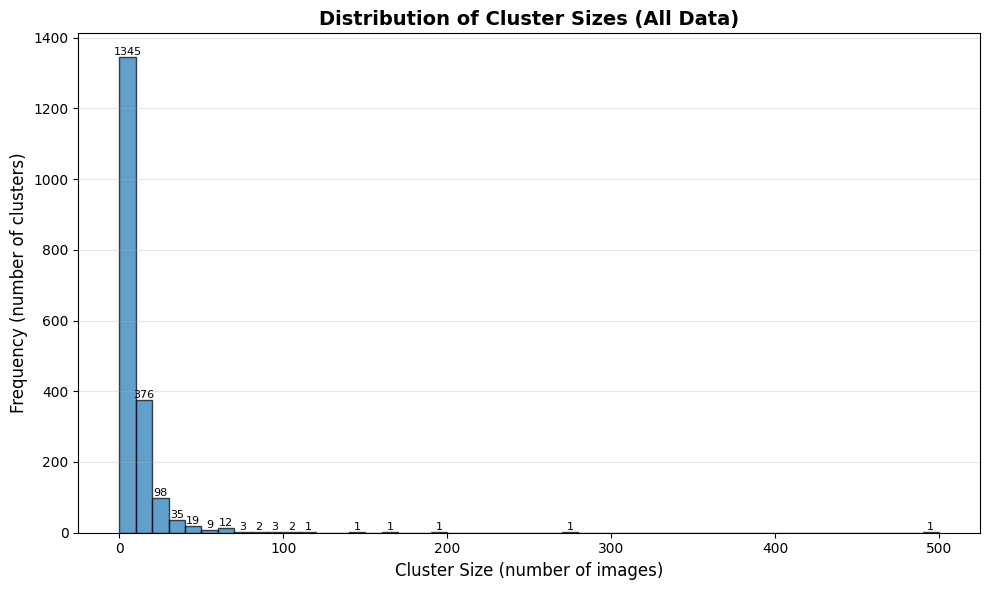


Filtered histogram (size <= 100):
  Clusters included: 1902 (99.6%)
  Clusters excluded: 8 (0.4%)


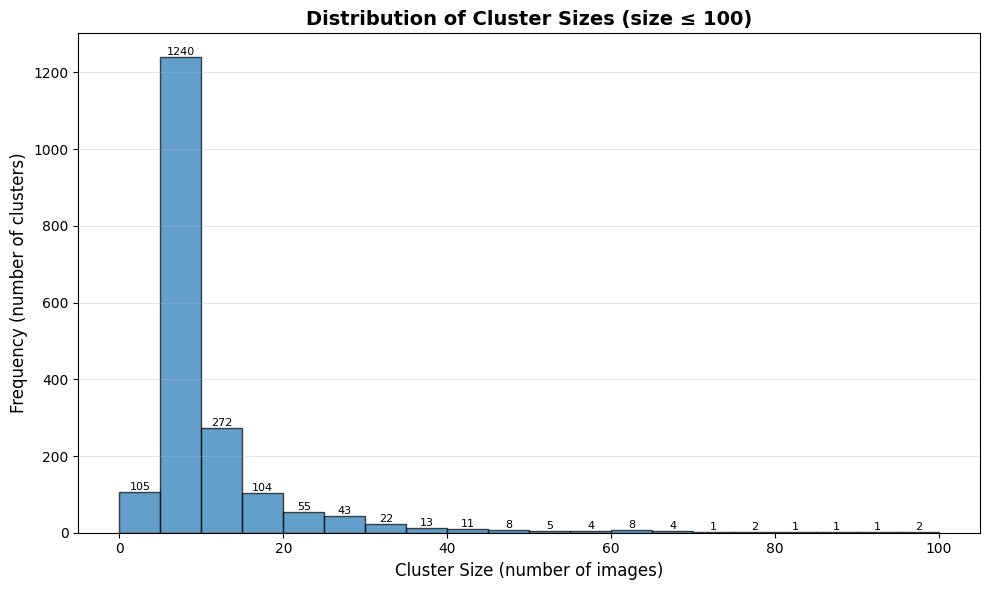


Cluster sizes JSON (cluster_id -> size):
{
  "1": 499,
  "2": 271,
  "3": 197,
  "4": 168,
  "5": 140,
  "6": 113,
  "7": 104,
  "8": 103,
  "9": 97,
  "10": 95,
  "11": 90,
  "12": 88,
  "13": 83,
  "14": 77,
  "15": 75,
  "16": 72,
  "17": 69,
  "18": 68,
  "19": 66,
  "20": 65,
  "21": 64,
  "22": 63,
  "23": 63,
  "24": 62,
  "25": 62,
  "26": 62,
  "27": 62,
  "28": 61,
  "29": 57,
  "30": 56,
  "31": 56,
  "32": 55,
  "33": 54,
  "34": 54,
  "35": 51,
  "36": 50,
  "37": 50,
  "38": 49,
  "39": 49,
  "40": 48,
  "41": 46,
  "42": 46,
  "43": 46,
  "44": 45,
  "45": 45,
  "46": 44,
  "47": 44,
  "48": 43,
  "49": 43,
  "50": 43,
  "51": 42,
  "52": 41,
  "53": 40,
  "54": 40,
  "55": 40,
  "56": 40,
  "57": 39,
  "58": 38,
  "59": 38,
  "60": 37,
  "61": 36,
  "62": 36,
  "63": 35,
  "64": 35,
  "65": 35,
  "66": 35,
  "67": 35,
  "68": 35,
  "69": 35,
  "70": 34,
  "71": 34,
  "72": 33,
  "73": 33,
  "74": 33,
  "75": 33,
  "76": 33,
  "77": 33,
  "78": 32,
  "79": 32,
  "80": 3

In [3]:
clusters_filepath = "../data/processed/clusters.json"

cluster_size_dict, cluster_sizes = compute_histogram(
    clusters_filepath=clusters_filepath,
    bin_width=10,
    filtered_bin_width=5,
    max_size_for_filtered=100,
    annotate_bars=True,
    show_cluster_sizes_json=True,
)

In [5]:
cluster_sizes[:20]

[499,
 271,
 197,
 168,
 140,
 113,
 104,
 103,
 97,
 95,
 90,
 88,
 83,
 77,
 75,
 72,
 69,
 68,
 66,
 65]